# Base CNN Training for Posture Classification (FP32)

**Architecture**
- 3 Conv2D layers with BatchNormalization
- Filter progression: [16, 16, 24]
- GlobalAveragePooling2D for efficiency
- Output: Dense(NUM_CLASSES, softmax)

**Hyperparameters**
- Learning rate: 0.001
- Batch size: 32
- Kernel size: (3, 3)
- L1 regularization: 1e-4
- Early stopping patience: 10

## Imports

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Keras 3
import keras
import keras_tuner

# TensorFlow
import tensorflow as tf

# Package imports
from neuroposasic.data import load_dataset, preprocess_data
from neuroposasic.model import (
    create_model,
    get_callbacks,
    train_model,
)
from neuroposasic.utils import (
    check_layer_trainable_params,
    plot_training_history,
    class_report_metric,
    save_model,
)

# Configure matplotlib for PDF export with serif font
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "Computer Modern Serif",
})

# Ensure figures directory exists
os.makedirs('figures', exist_ok=True)


I0000 00:00:1777550804.096787    5445 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Set random seed for reproducibility
np.random.seed(42)
keras.utils.set_random_seed(42)

# Constant number of postures
NUM_CLASSES = 3

# Check GPU
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Data

### Loading

In [3]:
# Load datasets using package function
X_train, y_train, X_val, y_val, X_test, y_test = load_dataset(type="raw")


Dataset shapes:
  Train: (119999, 64), labels: (119999,)
  Val:   (60000, 64), labels: (60000,)
  Test:  (120001, 64), labels: (120001,)


### Preprocessing

In [4]:
# Preprocess data using package function
(X_train, y_train, X_val, y_val, X_test, y_test, class_names) = preprocess_data(
    X_train, y_train, X_val, y_val, X_test, y_test,
    num_classes=NUM_CLASSES,
)


Label encoding:
  lateral_L -> 0
  lateral_R -> 1
  supine -> 2

One-hot encoded shape: 3

Reshaped data:
  Train: (119999, 8, 8, 1)
  Val:   (60000, 8, 8, 1)
  Test:  (120001, 8, 8, 1)

Data range: [0.0000, 233.4754]
Data dtype: float32


## Configuration

In [5]:
# Define callbacks using package function
callbacks = get_callbacks(model_name='base', patience=10)

Callbacks configured:
  - EarlyStopping
  - ReduceLROnPlateau
  - ModelCheckpoint


## Base Model

In [6]:
# Create and inspect model
base_model = create_model(num_classes=NUM_CLASSES)
base_model.summary()

check_layer_trainable_params(base_model)

I0000 00:00:1777550807.483446    5445 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5090 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3070, pci bus id: 0000:10:00.0, compute capability: 8.6


Model: "posture_classifier_base"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 6, 6, 16)       │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 6, 6, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 4, 4, 16)       │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 4, 4, 16)       │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 2, 2, 24)       │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (BatchNormalization)  │ (None, 2, 2, 24)       │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 1, 1, 24)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            75 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,203 (24.23 KB)

 Trainable params: 6,091 (23.79 KB)

 Non-trainable params: 112 (448.00 B)

conv_1: 144
conv_2: 2304
conv_3: 3456
output: 72


### Training

Epoch 1/50


I0000 00:00:1777550809.222928    5516 service.cc:153] XLA service 0x7f2cd8035ed0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777550809.222945    5516 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 3070, Compute Capability 8.6 (Driver: 13.2.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.21.1)
I0000 00:00:1777550809.271090    5516 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1777550809.497552    5516 cuda_dnn.cc:461] Loaded cuDNN version 92101
I0000 00:00:1777550809.513793    5516 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2575__.41


  75/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.4404 - loss: 1.3445

I0000 00:00:1777550813.279430    5516 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


3735/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7120 - loss: 0.6883

I0000 00:00:1777550818.773100    5517 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2575__.41


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7123 - loss: 0.6877
Epoch 1: val_loss improved from None to 0.44175, saving model to best_base_model.keras

Epoch 1: finished saving model to best_base_model.keras
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - accuracy: 0.7759 - loss: 0.5469 - val_accuracy: 0.8225 - val_loss: 0.4417 - learning_rate: 0.0010
Epoch 2/50
3730/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8374 - loss: 0.4076
Epoch 2: val_loss improved from 0.44175 to 0.35669, saving model to best_base_model.keras

Epoch 2: finished saving model to best_base_model.keras
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.8440 - loss: 0.3928 - val_accuracy: 0.8601 - val_loss: 0.3567 - learning_rate: 0.0010
Epoch 3/50
3718/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8574 - loss: 0.3607
Epoch 3: val_loss improved from 0.35669 to 0.34650, saving model to best_base_model.keras

Epoch 3: finished saving model to best_base_model.keras
3750/3750 ━━━━━━━━━━━━

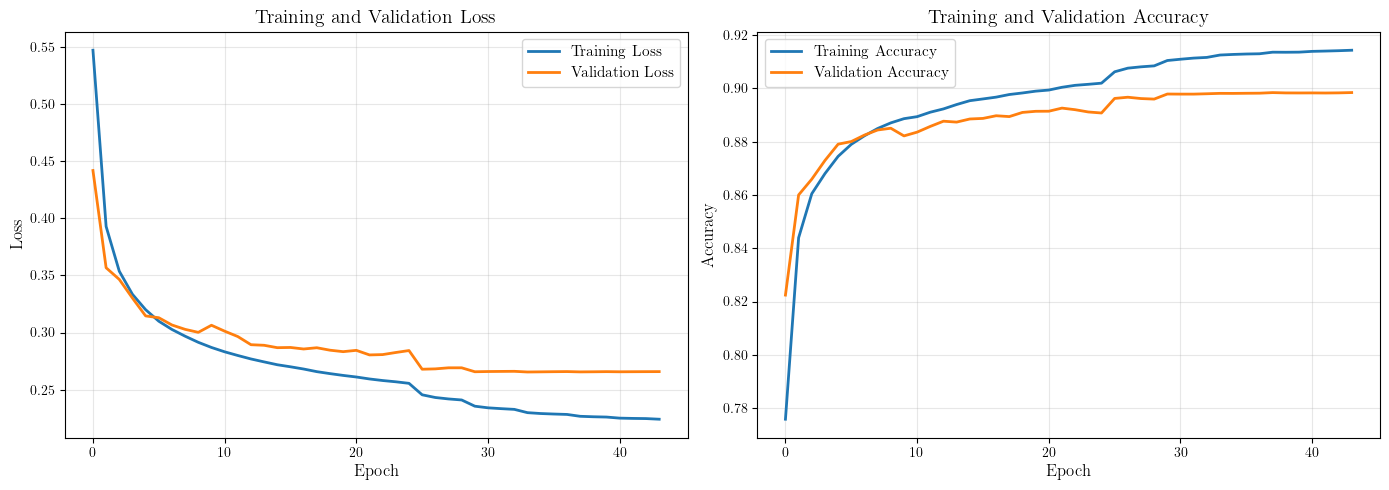

In [7]:
# Train the model
base_history = train_model(
    base_model, X_train, y_train, X_val, y_val, callbacks,
    batch_size=32, epochs=50,
)
plot_training_history(base_history, model_name='posture_classifier_base', save=True)

## Tuned Model

Hyperparameter optimization (KerasTuner)

In [14]:
tuner = keras_tuner.Hyperband(
    hypermodel=create_model,
    objective='val_accuracy',
    max_epochs=10,
    factor=3,
    hyperband_iterations=2,
    overwrite=True,
    directory='tuning',
    project_name='posture_cnn',
    )

tuner.search_space_summary()

Search space summary
Default search space size: 4
filters_1 (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 16, 'step': 4, 'sampling': 'linear'}
filters_2 (Int)
{'default': None, 'conditions': [], 'min_value': 4, 'max_value': 16, 'step': 4, 'sampling': 'linear'}
filters_3 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 24, 'step': 4, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.001, 'conditions': [], 'values': [0.001, 0.0001], 'ordered': True}


In [15]:
tuner.search(X_train, y_train, epochs=10, validation_data=(X_val, y_val))
tuned_model = tuner.get_best_models()[0]

tuned_model.summary()

check_layer_trainable_params(tuned_model)

Trial 60 Complete [00h 01m 15s]
val_accuracy: 0.8157833218574524

Best val_accuracy So Far: 0.8867999911308289
Total elapsed time: 00h 33m 48s


Model: "posture_classifier_tuned"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ pressure_map (InputLayer)       │ (None, 8, 8, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_1 (Conv2D)                 │ (None, 6, 6, 12)       │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_1 (BatchNormalization)  │ (None, 6, 6, 12)       │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_2 (Conv2D)                 │ (None, 4, 4, 12)       │         1,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_2 (BatchNormalization)  │ (None, 4, 4, 12)       │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_3 (Conv2D)                 │ (None, 2, 2, 20)       │         2,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv_3 (BatchNormalization)  │ (None, 2, 2, 20)       │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 1, 1, 20)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,803 (14.86 KB)

 Trainable params: 3,715 (14.51 KB)

 Non-trainable params: 88 (352.00 B)

conv_1: 108
conv_2: 1296
conv_3: 2160
output: 60


### Training

Epoch 1/50


I0000 00:00:1777553785.585413    5515 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7276844__.41


3730/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8788 - loss: 0.3065

I0000 00:00:1777553792.002797    5516 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_7276844__.41


3750/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8788 - loss: 0.3065
Epoch 1: val_loss did not improve from 0.22745
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - accuracy: 0.8792 - loss: 0.3079 - val_accuracy: 0.8874 - val_loss: 0.2903 - learning_rate: 0.0010
Epoch 2/50
3727/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8810 - loss: 0.3032
Epoch 2: val_loss did not improve from 0.22745
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8808 - loss: 0.3049 - val_accuracy: 0.8885 - val_loss: 0.2886 - learning_rate: 0.0010
Epoch 3/50
3747/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8819 - loss: 0.3007
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 0.22745
3750/3750 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - accuracy: 0.8818 - loss: 0.3025 - val_accuracy: 0.8871 - val_loss: 0.2919 - learning_rate: 0.0010
Epoch 4/50
3726/3750 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8861 - loss: 0.2908
Epoch 4: va

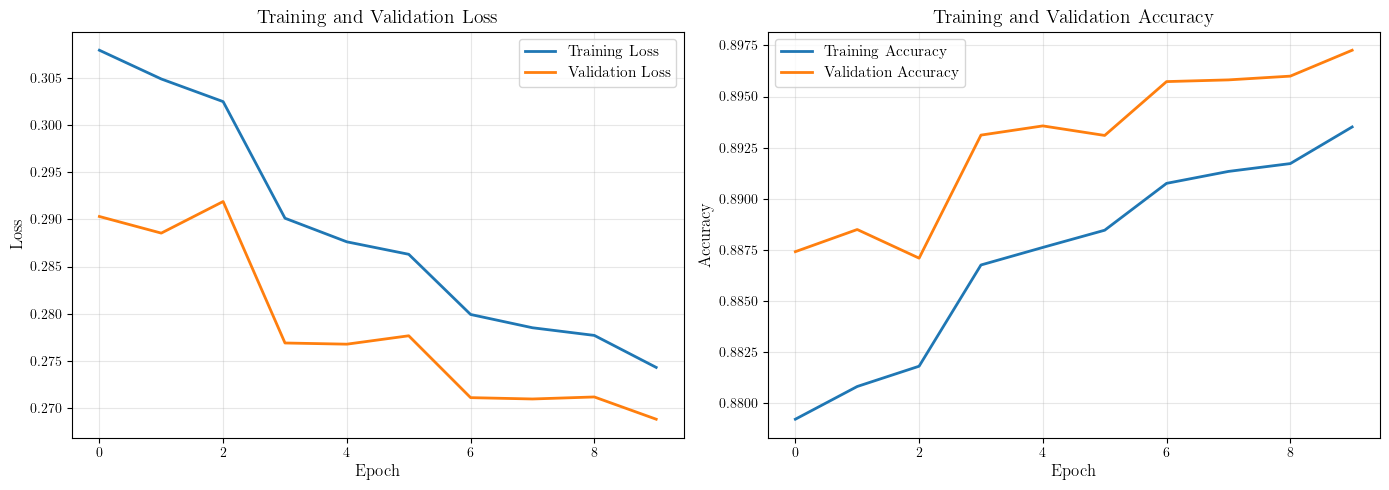

In [16]:
tuned_history = train_model(tuned_model, X_train, y_train, X_val, y_val, callbacks)
plot_training_history(tuned_history, model_name='posture_classifier_tuned', save=True)

## Model Evaluation

### Base Model

In [17]:
# Classification report for base model
class_report_metric(base_model, X_test, y_test, class_names)


Accuracy Report for `posture_classifier_base`:
  Loss: 0.2692
  Accuracy: 89.73%

Classification Report for `posture_classifier_base`:
              precision    recall  f1-score   support

   lateral_L     0.9146    0.8837    0.8989     40000
   lateral_R     0.8819    0.9078    0.8947     40000
      supine     0.8965    0.9004    0.8984     40001

    accuracy                         0.8973    120001
   macro avg     0.8977    0.8973    0.8973    120001
weighted avg     0.8977    0.8973    0.8973    120001



### Tuned Model

In [18]:
# Classification report for tuned model
class_report_metric(tuned_model, X_test, y_test, class_names)


Accuracy Report for `posture_classifier_tuned`:
  Loss: 0.2948
  Accuracy: 88.56%

Classification Report for `posture_classifier_tuned`:
              precision    recall  f1-score   support

   lateral_L     0.9161    0.8586    0.8864     40000
   lateral_R     0.8849    0.8804    0.8826     40000
      supine     0.8593    0.9177    0.8876     40001

    accuracy                         0.8856    120001
   macro avg     0.8868    0.8856    0.8855    120001
weighted avg     0.8868    0.8856    0.8855    120001



## Model Saving

In [19]:
# Save models
save_model(base_model, output_dir='output')
save_model(tuned_model, output_dir='output')


Model saved to: output/posture_classifier_base.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_base
  Total parameters: 6,203

Model saved to: output/posture_classifier_tuned.keras

Verification:
  Loaded successfully: True
  Model name: posture_classifier_tuned
  Total parameters: 3,803
